In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & split ─────────────────────────────────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]

train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

LOOKBACK      = 3 * 252      # 3 years: EMRT / OLS estimation window
LOOKBACK_SYN  = LOOKBACK     # 3-year OLS for synthetic param estimation
EPISODE_LEN   = 3 * 252      # 3-year episodes
EP_LEN_FULL   = 3 + EPISODE_LEN

# State: [spread, z_30, z_100, spread_ret_1, spread_ret_2, position]
Z_WINDOWS = [30, 100]
STATE_DIM = 1 + len(Z_WINDOWS) + 2 + 1   # = 6

REAL_T_MIN = LOOKBACK
REAL_T_MAX = train_end - EP_LEN_FULL
SYN_T_MAX  = train_end - LOOKBACK_SYN

def sample_real(t0):
    return prices[:, t0 : t0 + EP_LEN_FULL]

print(f'N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})')
print(f'LOOKBACK={LOOKBACK}  EPISODE_LEN={EPISODE_LEN}  STATE_DIM={STATE_DIM}')
print(f'Z_WINDOWS={Z_WINDOWS}  |  REAL_T range: [{REAL_T_MIN}, {REAL_T_MAX}]')

N=5032  |  train [0, 3774)  |  test [3774, 5032)
LOOKBACK=756  EPISODE_LEN=756  STATE_DIM=6
Z_WINDOWS=[30, 100]  |  REAL_T range: [756, 3015]


In [3]:
# ── EMRT beta selection (used for real windows) ───────────────────────────
C_EMRT    = 1.0
BETA_GRID = np.arange(0.1, 3.01, 0.01)

def fit_window_emrt(t0, C=C_EMRT):
    A = log_A[t0 - LOOKBACK : t0]
    B = log_B[t0 - LOOKBACK : t0]
    n = LOOKBACK
    K = len(BETA_GRID)

    Y_mat  = A[np.newaxis, :] - BETA_GRID[:, np.newaxis] * B[np.newaxis, :]
    stds   = Y_mat.std(axis=1, ddof=1)
    mus    = Y_mat.mean(axis=1)
    thresh = C * stds

    lmax = np.maximum.accumulate(Y_mat, axis=1)
    lmin = np.minimum.accumulate(Y_mat, axis=1)
    rmax = np.maximum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]
    rmin = np.minimum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]

    Ym = Y_mat[:, 1:-1]
    imp = (
        ((Ym <= Y_mat[:, :-2]) & (Ym <= Y_mat[:, 2:]) &
         (lmax[:, :-2] - Ym >= thresh[:, None]) &
         (rmax[:, 2:]  - Ym >= thresh[:, None])) |
        ((Ym >= Y_mat[:, :-2]) & (Ym >= Y_mat[:, 2:]) &
         (Ym - lmin[:, :-2] >= thresh[:, None]) &
         (Ym - rmin[:, 2:]  >= thresh[:, None]))
    )

    emrts = np.full(K, np.inf)
    for k in range(K):
        if stds[k] < 1e-10:
            continue
        ext = np.where(imp[k])[0] + 1
        if len(ext) == 0:
            continue
        Y_k = Y_mat[k]; mu_k = mus[k]
        taus = [int(ext[0])]; epos = 1
        while True:
            prev  = taus[-1]
            seg   = Y_k[prev:] - mu_k
            xings = np.where(seg[:-1] * seg[1:] <= 0)[0]
            if xings.size == 0:
                break
            cross = prev + int(xings[0]) + 1
            taus.append(cross)
            while epos < len(ext) and ext[epos] <= cross:
                epos += 1
            if epos >= len(ext):
                break
            taus.append(int(ext[epos])); epos += 1
        N_tau = len(taus)
        if N_tau >= 2:
            total = sum(taus[i] - taus[i-1] for i in range(1, N_tau, 2))
            emrts[k] = (2.0 / N_tau) * total

    best_k = int(np.argmin(emrts))
    beta   = float(BETA_GRID[best_k])
    spread = A - beta * B
    icp    = float(np.mean(spread))
    return beta, icp, 0.0, float(np.std(spread - icp, ddof=1))

print('EMRT ready.')

EMRT ready.


In [4]:
# ── Synthetic window generator ────────────────────────────────────────────
# 1. Sample random 3-year block from training data
# 2. OLS → beta, intercept
# 3. Fit AR(1) to spread, GBM to log_B
# 4. Simulate EP_LEN_FULL bars of synthetic prices

def make_synthetic_window(rng_obj):
    # ── OLS on 3-year block ───────────────────────────────────────────────
    t0_ols  = int(rng_obj.integers(0, SYN_T_MAX + 1))
    A_ols   = log_A[t0_ols : t0_ols + LOOKBACK_SYN]
    B_ols   = log_B[t0_ols : t0_ols + LOOKBACK_SYN]

    X       = np.column_stack([np.ones(LOOKBACK_SYN), B_ols])
    coef, _, _, _ = np.linalg.lstsq(X, A_ols, rcond=None)
    icp, b  = float(coef[0]), float(coef[1])

    spread  = A_ols - b * B_ols - icp   # demeaned by construction (OLS residual)

    # ── AR(1) on spread ───────────────────────────────────────────────────
    S_lag   = spread[:-1]
    S_now   = spread[1:]
    var_lag = float(np.var(S_lag, ddof=1))
    rho     = float(np.cov(S_lag, S_now, ddof=1)[0, 1] / (var_lag + 1e-12))
    rho     = float(np.clip(rho, -0.9999, 0.9999))
    a_ar1   = float(np.mean(S_now) - rho * np.mean(S_lag))
    sig_eps = float(np.std(S_now - (a_ar1 + rho * S_lag), ddof=1))

    # ── GBM params for log_B ─────────────────────────────────────────────
    dB    = np.diff(B_ols)
    mu_B  = float(dB.mean())
    sig_B = float(dB.std(ddof=1))

    # ── Simulate EP_LEN_FULL steps ────────────────────────────────────────
    T = EP_LEN_FULL
    noise_S = rng_obj.standard_normal(T - 1)
    noise_B = rng_obj.standard_normal(T - 1)

    sim_logB    = np.empty(T)
    sim_S       = np.empty(T)
    sim_logB[0] = B_ols[-1]   # continue from end of estimation window
    sim_S[0]    = 0.0          # start spread at its mean

    for t in range(1, T):
        sim_logB[t] = sim_logB[t-1] + mu_B + sig_B * noise_B[t-1]
        sim_S[t]    = a_ar1 + rho * sim_S[t-1] + sig_eps * noise_S[t-1]

    sim_logA   = sim_S + b * sim_logB + icp
    syn_prices = np.exp(np.stack([sim_logA, sim_logB]))   # (2, T)
    return syn_prices, b, icp


# Quick sanity: one synthetic episode
_p, _b, _icp = make_synthetic_window(rng)
print(f'Synthetic test: prices shape={_p.shape}  beta={_b:.3f}  icp={_icp:.4f}')
_spread = np.log(_p[0]) - _b * np.log(_p[1]) - _icp
print(f'Spread: mean={_spread.mean():.4f}  std={_spread.std():.4f}  '
      f'AR(1)ρ≈{np.corrcoef(_spread[:-1], _spread[1:])[0,1]:.3f}')

Synthetic test: prices shape=(2, 759)  beta=0.468  icp=2.2392
Spread: mean=-0.0065  std=0.0580  AR(1)ρ≈0.978


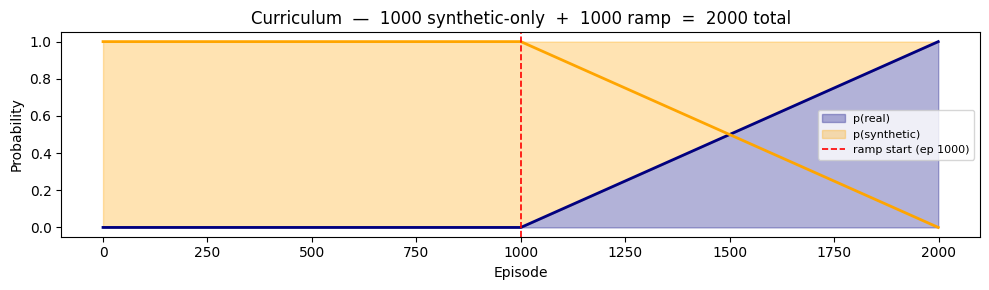

In [5]:
# ── Curriculum schedule ───────────────────────────────────────────────────
# Episodes [0, SYN_ONLY_EPS)          → 100% synthetic
# Episodes [SYN_ONLY_EPS, N_EPISODES) → p_real ramps linearly 0 → 1

N_EPISODES   = 2000
SYN_ONLY_EPS = 1000    # pure-synthetic warm-up

ep_axis = np.arange(N_EPISODES)
ramp    = np.clip((ep_axis - SYN_ONLY_EPS) / max(N_EPISODES - SYN_ONLY_EPS - 1, 1), 0.0, 1.0)

fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(ep_axis, 0, ramp,        color='navy',   alpha=0.3, label='p(real)')
ax.fill_between(ep_axis, ramp, 1,        color='orange', alpha=0.3, label='p(synthetic)')
ax.plot(ep_axis, ramp,       color='navy',   lw=2)
ax.plot(ep_axis, 1 - ramp,   color='orange', lw=2)
ax.axvline(SYN_ONLY_EPS, color='red', lw=1.2, ls='--', label=f'ramp start (ep {SYN_ONLY_EPS})')
ax.set_xlabel('Episode')
ax.set_ylabel('Probability')
ax.set_title(f'Curriculum  —  {SYN_ONLY_EPS} synthetic-only  +  {N_EPISODES - SYN_ONLY_EPS} ramp  =  {N_EPISODES} total')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [6]:
# ── Agent — state_dim=STATE_DIM (spread, z_30, z_100, ret1, ret2, pos) ───
agent = DoubleDQN(
    state_dim       = STATE_DIM,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = int(N_EPISODES * EPISODE_LEN * 0.8),
    grad_clip       = 1.0,
)
print(f'Agent ready  |  state_dim={STATE_DIM}  |  eps_decay over {agent.eps_decay_steps:,} steps')

Agent ready  |  state_dim=6  |  eps_decay over 1,209,600 steps


ep   100 | real   0 syn 100 | p_real=0.00 | avg_reward  +454.83 | avg_wealth 10454.83 | eps 0.941
ep   200 | real   0 syn 100 | p_real=0.00 | avg_reward  +764.63 | avg_wealth 10764.63 | eps 0.881
ep   300 | real   0 syn 100 | p_real=0.00 | avg_reward  +929.18 | avg_wealth 10929.18 | eps 0.822
ep   400 | real   0 syn 100 | p_real=0.00 | avg_reward +1439.50 | avg_wealth 11439.50 | eps 0.762
ep   500 | real   0 syn 100 | p_real=0.00 | avg_reward +1597.66 | avg_wealth 11597.66 | eps 0.703
ep   600 | real   0 syn 100 | p_real=0.00 | avg_reward +1534.87 | avg_wealth 11534.87 | eps 0.644
ep   700 | real   0 syn 100 | p_real=0.00 | avg_reward +1870.90 | avg_wealth 11870.90 | eps 0.584
ep   800 | real   0 syn 100 | p_real=0.00 | avg_reward +2452.10 | avg_wealth 12452.10 | eps 0.525
ep   900 | real   0 syn 100 | p_real=0.00 | avg_reward +2522.35 | avg_wealth 12522.35 | eps 0.466
ep  1000 | real   0 syn 100 | p_real=0.00 | avg_reward +2771.27 | avg_wealth 12771.27 | eps 0.406
ep  1100 | real   6 

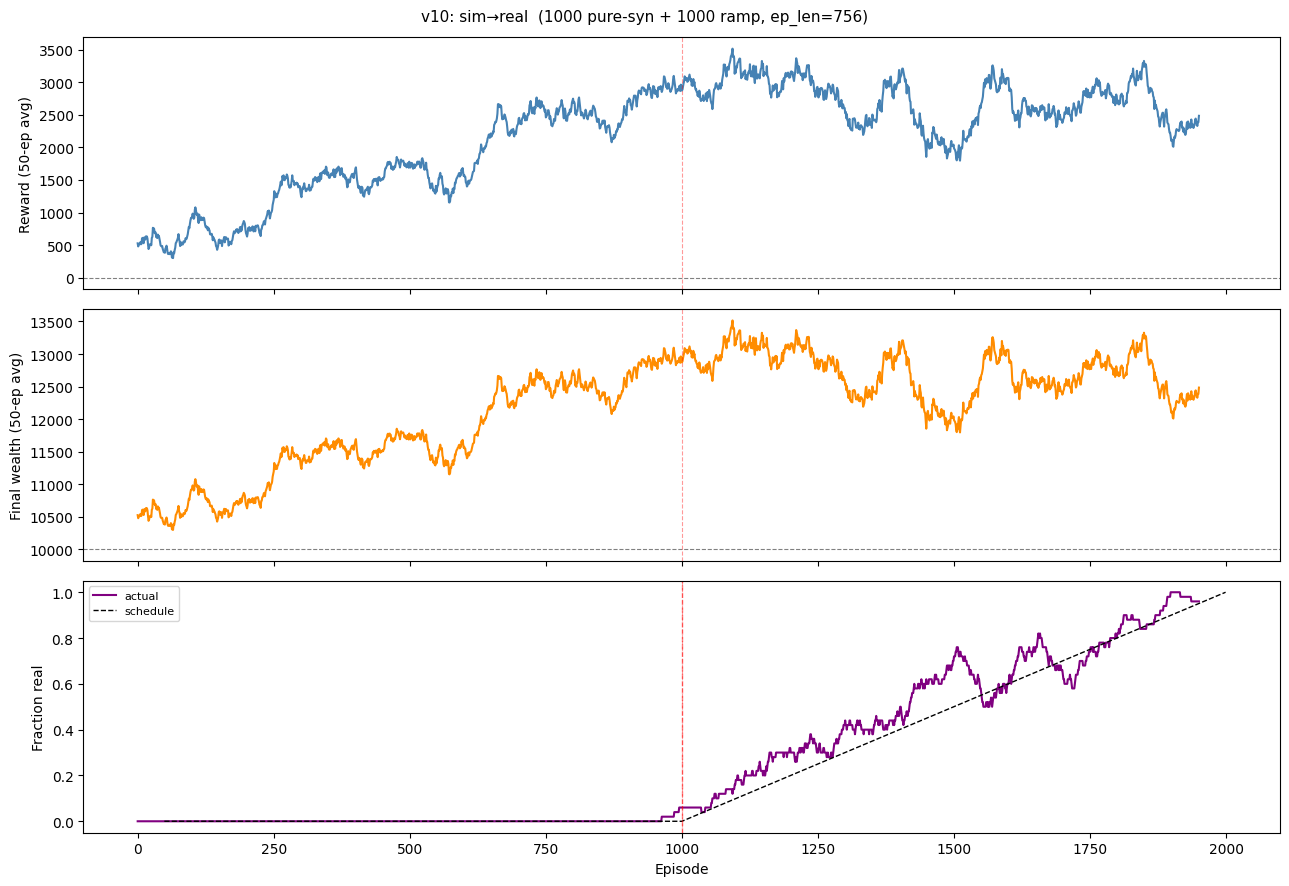

In [7]:
# ── Training — curriculum: synthetic-only → gradual real ─────────────────
TRAIN_FREQ = 4
LOG_EVERY  = 100

ep_rewards  = []
ep_wealth   = []
ep_eps      = []
ep_is_real  = []
losses      = []
total_steps = 0

for ep in range(N_EPISODES):
    # Curriculum: flat 0 until SYN_ONLY_EPS, then linear ramp to 1
    if ep < SYN_ONLY_EPS:
        p_real = 0.0
    else:
        p_real = (ep - SYN_ONLY_EPS) / max(N_EPISODES - SYN_ONLY_EPS - 1, 1)

    use_real = (rng.random() < p_real)

    if use_real:
        t0 = int(rng.integers(REAL_T_MIN, REAL_T_MAX + 1))
        b, icp, _, _ = fit_window_emrt(t0)
        ep_prices = sample_real(t0)
    else:
        ep_prices, b, icp = make_synthetic_window(rng)

    env = PairTradingEnv(
        ep_prices,
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=EPISODE_LEN, z_windows=Z_WINDOWS, simple_obs=True,
    )

    obs, _ = env.reset()
    done    = False
    ep_r    = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)
    ep_is_real.append(use_real)

    if (ep + 1) % LOG_EVERY == 0:
        blk = ep_is_real[-LOG_EVERY:]
        n_r = sum(blk)
        print(f'ep {ep+1:5d} | real {n_r:3d} syn {LOG_EVERY-n_r:3d} | '
              f'p_real={p_real:.2f} | '
              f'avg_reward {np.mean(ep_rewards[-LOG_EVERY:]):+8.2f} | '
              f'avg_wealth {np.mean(ep_wealth[-LOG_EVERY:]):8.2f} | '
              f'eps {agent.epsilon:.3f}')

# ── Training curves ───────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll
ep_is_real_f = np.array(ep_is_real, dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f'v10: sim→real  ({SYN_ONLY_EPS} pure-syn + {N_EPISODES-SYN_ONLY_EPS} ramp, '
             f'ep_len={EPISODE_LEN})', fontsize=11)

axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel(f'Reward ({roll}-ep avg)')

axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel(f'Final wealth ({roll}-ep avg)')

axes[2].plot(np.convolve(ep_is_real_f, kern, mode='valid'), color='purple', label='actual')
axes[2].plot(ep_axis[roll-1:], ramp[roll-1:], color='black', lw=1, ls='--', label='schedule')
axes[2].axvline(SYN_ONLY_EPS, color='red', lw=1, ls='--', alpha=0.5)
axes[2].set_ylabel('Fraction real')
axes[2].set_xlabel('Episode')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.axvline(SYN_ONLY_EPS, color='red', lw=0.8, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
# ── Evaluation helpers ────────────────────────────────────────────────────
_RF_DAILY = (1.05) ** (1.0 / 252) - 1.0

def evaluate(env, agent):
    obs, _ = env.reset()
    t0 = env._t
    wealth = [env._wealth()]
    # obs[1] = z_30 (index 1 in 6-feature state); fallback to obs[0] for 2-feature
    _z_idx = 1 if len(obs) > 2 else 0
    z_hist = [float(obs[_z_idx])]
    pos_hist = []
    entries_long, entries_short, exits = [], [], []
    step = 0
    done = False

    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[_z_idx]))
        if env._pos != prev_pos:
            if   env._pos ==  1: entries_long.append(step)
            elif env._pos == -1: entries_short.append(step)
            else:                exits.append(step)
        step += 1

    return dict(wealth=np.array(wealth), z=np.array(z_hist),
                pos=np.array(pos_hist), t_start=t0,
                entries_long=entries_long, entries_short=entries_short, exits=exits)


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    exc = ret - _RF_DAILY
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = exc.mean() / (exc.std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:55s}  ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:5.1f}%')


def plot_result(res, title=''):
    t0    = res['t_start']
    steps = len(res['z']) - 1
    t_idx = np.arange(t0, t0 + steps + 1)
    W     = res['wealth']
    bench = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title, fontsize=11)

    axes[0].plot(t_idx, W,     color='navy', label='strategy')
    axes[0].plot(t_idx, bench, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    ax_z = axes[1]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')

    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')
    for i in res['entries_long']:  ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']: ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:         ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)

    z_label = f'Z-score ({Z_WINDOWS[0]}-bar rolling)'
    ax_z.set_ylabel(z_label)
    ax_z.set_xlabel('Time index')
    ax_z.set_title(f'long: {len(res["entries_long"])}  short: {len(res["entries_short"])}  exits: {len(res["exits"])}')
    plt.tight_layout()
    plt.show()

=== Test set (5 × 252-bar windows) ===
Test yr 1  [3774–4530)  β=0.470                          $    9378  ret   -6.2%  Sharpe -0.78  MDD -17.6%


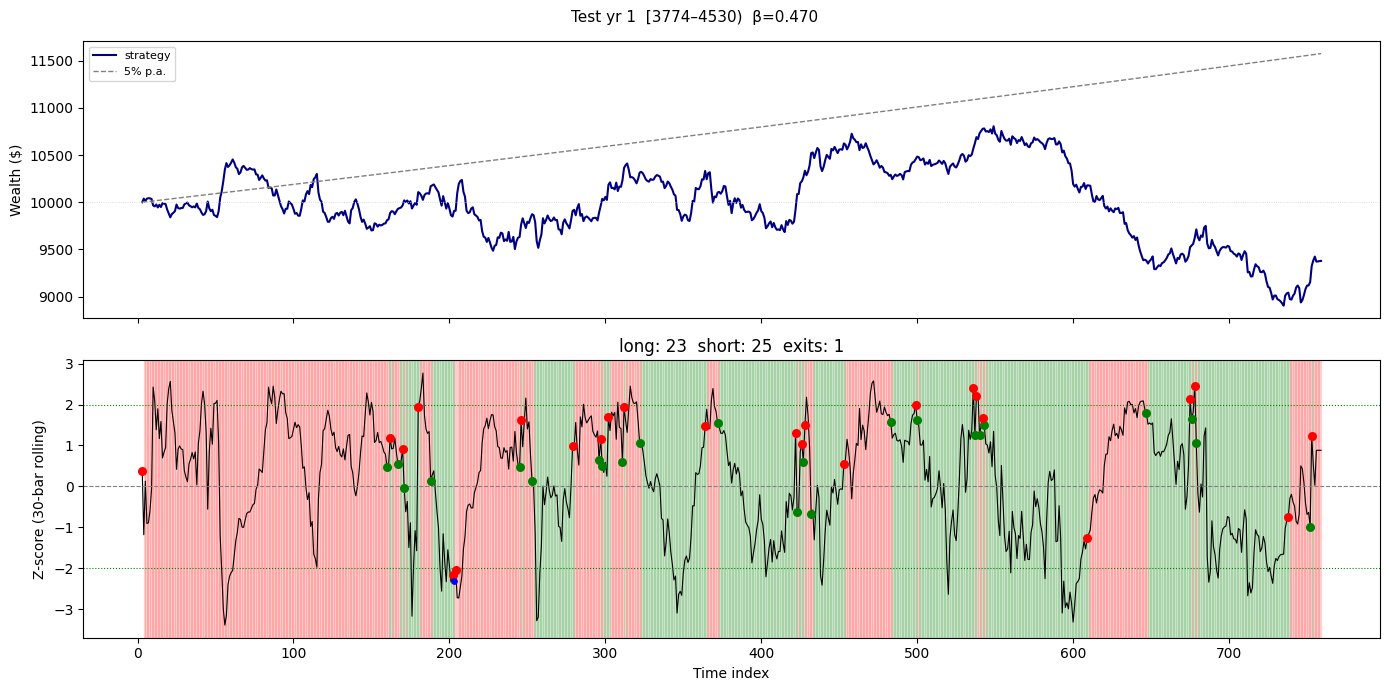

Test yr 2  [4530–5031)  β=1.360                          $   13409  ret  +34.1%  Sharpe  1.06  MDD  -5.3%


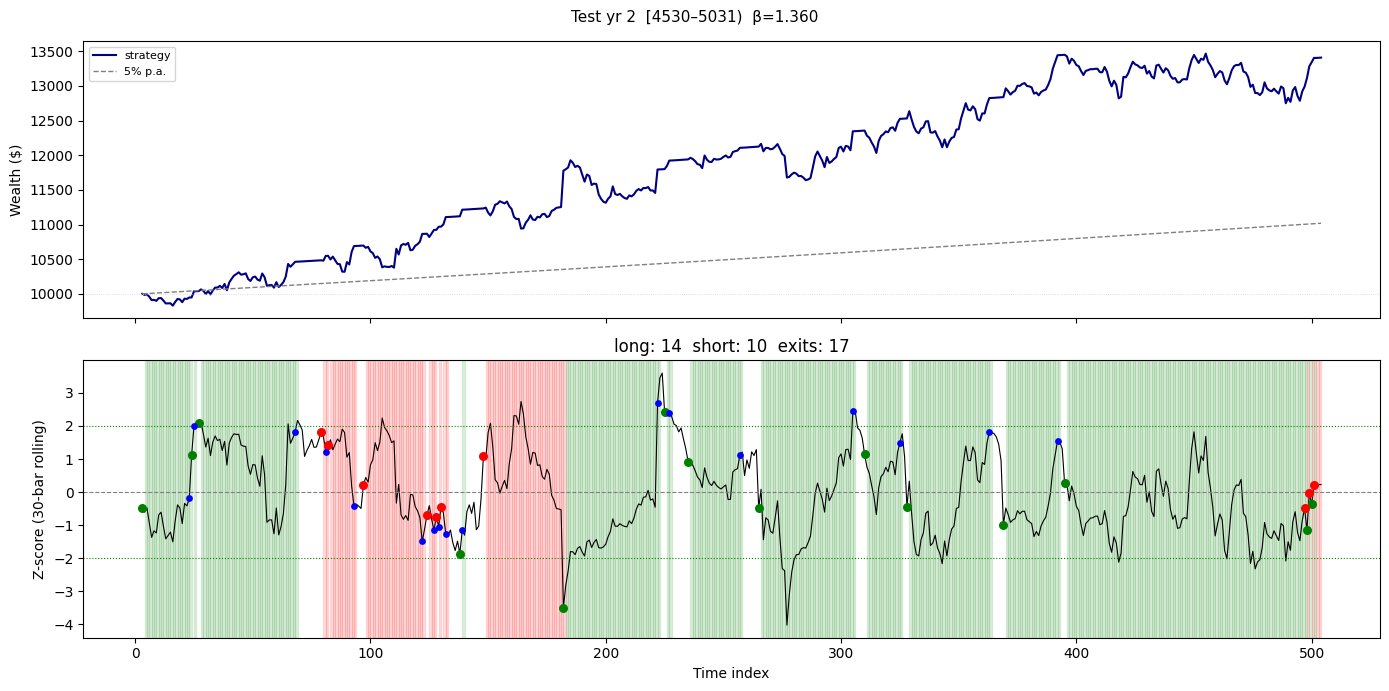

In [9]:
# ── Test: 5 disjoint yearly windows ──────────────────────────────────────
print('=== Test set (5 × 252-bar windows) ===')

for k in range(5):
    t0     = train_end + k * EPISODE_LEN
    ep_len = min(EPISODE_LEN, N - t0 - 1)
    if ep_len <= 0:
        break

    b, icp, _, _ = fit_window_emrt(t0)
    test_env = PairTradingEnv(
        prices[:, t0 : t0 + ep_len + 1],
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=ep_len, z_windows=Z_WINDOWS, simple_obs=True,
    )

    res   = evaluate(test_env, agent)
    label = f'Test yr {k+1}  [{t0}–{t0+ep_len})  β={b:.3f}'
    metrics(res['wealth'], label)
    plot_result(res, title=label)

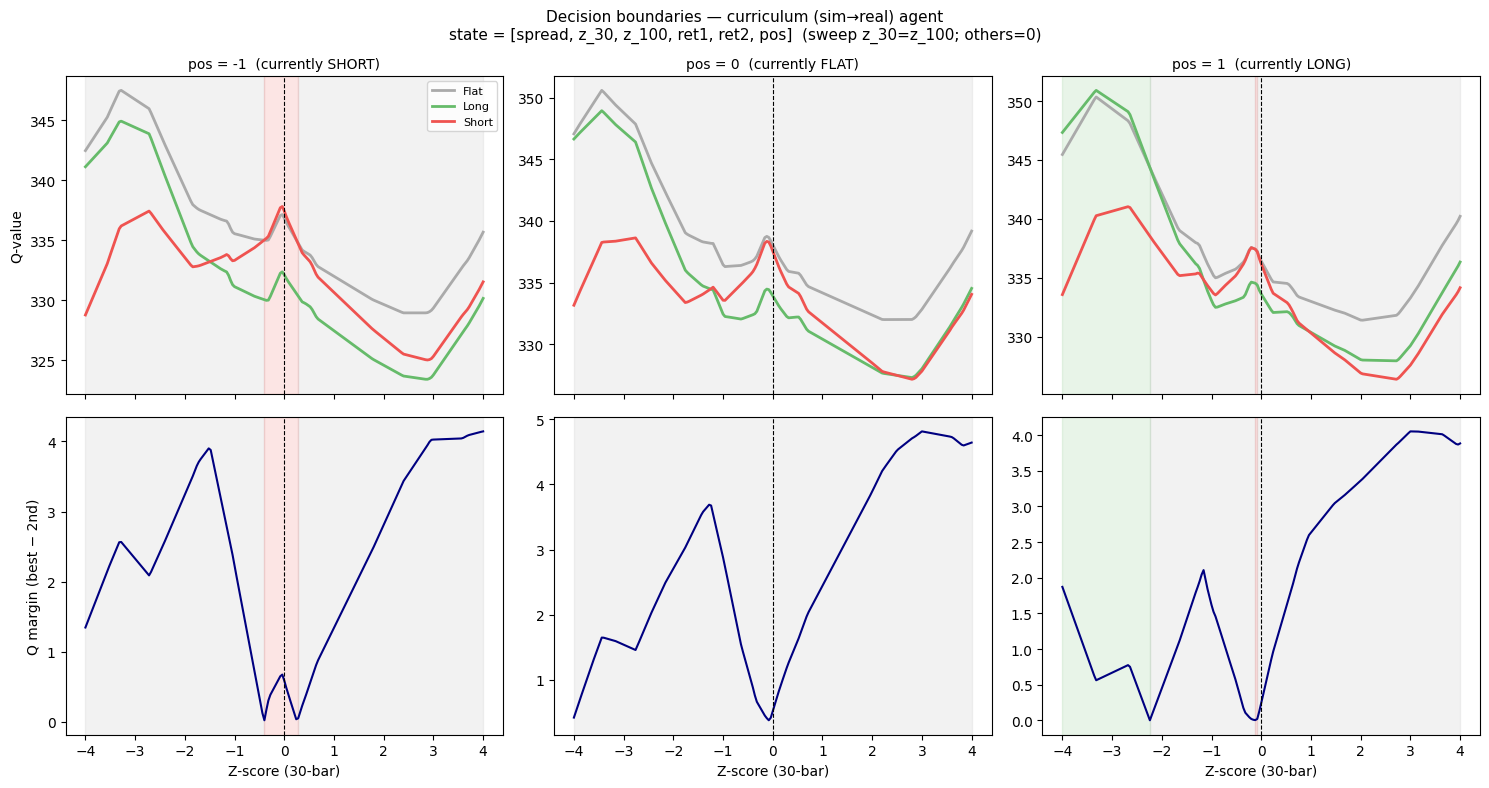


Action thresholds:
  pos=-1:   z=-0.40: Flat→Short  z=+0.28: Short→Flat
  pos=+0:   always Flat
  pos=+1:   z=-2.24: Long→Flat  z=-0.12: Flat→Short  z=-0.08: Short→Flat


In [10]:
# ── Decision boundaries — curriculum (sim→real) agent ────────────────────
# State = [spread, z_30, z_100, ret1, ret2, pos]
# To visualise: fix spread=0, z_100=z_30, ret1=ret2=0; sweep z_30 and vary pos.

ACT_NAMES  = {0: 'Flat', 1: 'Long', 2: 'Short'}
ACT_COLORS = {0: '#aaaaaa', 1: '#66bb6a', 2: '#ef5350'}
POS_LABELS = {-1: 'currently SHORT', 0: 'currently FLAT', 1: 'currently LONG'}

z_vals    = np.linspace(-4.0, 4.0, 201)
positions = [-1, 0, 1]

agent.q_net.eval()
Q_all = np.zeros((3, len(z_vals), 3))
with torch.no_grad():
    for pi, pos in enumerate(positions):
        for zi, z in enumerate(z_vals):
            # [spread=0, z_30=z, z_100=z, ret1=0, ret2=0, pos]
            obs = torch.tensor([0.0, z, z, 0.0, 0.0, float(pos)], dtype=torch.float32).unsqueeze(0)
            Q_all[pi, zi] = agent.q_net(obs).numpy()[0]
agent.q_net.train()

best_action = Q_all.argmax(axis=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle('Decision boundaries — curriculum (sim→real) agent\n'
             'state = [spread, z_30, z_100, ret1, ret2, pos]  '
             '(sweep z_30=z_100; others=0)', fontsize=11)

for pi, pos in enumerate(positions):
    ax_q = axes[0, pi]
    ax_m = axes[1, pi]

    prev_a    = best_action[pi, 0]
    seg_start = z_vals[0]
    for zi in range(1, len(z_vals)):
        a = best_action[pi, zi]
        if a != prev_a or zi == len(z_vals) - 1:
            ax_q.axvspan(seg_start, z_vals[zi], alpha=0.15, color=ACT_COLORS[prev_a])
            ax_m.axvspan(seg_start, z_vals[zi], alpha=0.15, color=ACT_COLORS[prev_a])
            seg_start = z_vals[zi]
            prev_a = a

    for a in range(3):
        ax_q.plot(z_vals, Q_all[pi, :, a], color=ACT_COLORS[a], lw=2, label=ACT_NAMES[a])
    ax_q.axvline(0, color='black', lw=0.8, ls='--')
    ax_q.set_title(f'pos = {pos}  ({POS_LABELS[pos]})', fontsize=10)
    ax_q.set_ylabel('Q-value' if pi == 0 else '')
    if pi == 0:
        ax_q.legend(fontsize=8)

    sorted_Q = np.sort(Q_all[pi], axis=1)
    margin   = sorted_Q[:, -1] - sorted_Q[:, -2]
    ax_m.plot(z_vals, margin, color='navy', lw=1.5)
    ax_m.axvline(0, color='black', lw=0.8, ls='--')
    ax_m.set_xlabel('Z-score (30-bar)')
    ax_m.set_ylabel('Q margin (best − 2nd)' if pi == 0 else '')

plt.tight_layout()
plt.show()

print('\nAction thresholds:')
for pi, pos in enumerate(positions):
    changes = []
    for zi in range(1, len(z_vals)):
        if best_action[pi, zi] != best_action[pi, zi-1]:
            changes.append((z_vals[zi], ACT_NAMES[best_action[pi, zi-1]],
                            ACT_NAMES[best_action[pi, zi]]))
    print(f'  pos={pos:+d}: ', end='')
    if changes:
        for z, a_from, a_to in changes:
            print(f'  z={z:+.2f}: {a_from}→{a_to}', end='')
    else:
        print(f'  always {ACT_NAMES[best_action[pi, 0]]}', end='')
    print()

ep   100 | avg_reward  +812.63 | avg_wealth 10812.63 | eps 0.941
ep   200 | avg_reward +1098.57 | avg_wealth 11098.57 | eps 0.881
ep   300 | avg_reward +1146.52 | avg_wealth 11146.52 | eps 0.822
ep   400 | avg_reward +1412.68 | avg_wealth 11412.68 | eps 0.762
ep   500 | avg_reward +1608.64 | avg_wealth 11608.64 | eps 0.703
ep   600 | avg_reward +1840.38 | avg_wealth 11840.38 | eps 0.644
ep   700 | avg_reward +1753.30 | avg_wealth 11753.30 | eps 0.584
ep   800 | avg_reward +1903.98 | avg_wealth 11903.98 | eps 0.525
ep   900 | avg_reward +2581.75 | avg_wealth 12581.75 | eps 0.466
ep  1000 | avg_reward +3016.91 | avg_wealth 13016.91 | eps 0.406
ep  1100 | avg_reward +2994.36 | avg_wealth 12994.36 | eps 0.347
ep  1200 | avg_reward +3024.92 | avg_wealth 13024.92 | eps 0.287
ep  1300 | avg_reward +3876.29 | avg_wealth 13876.29 | eps 0.228
ep  1400 | avg_reward +4082.91 | avg_wealth 14082.91 | eps 0.169
ep  1500 | avg_reward +4304.95 | avg_wealth 14304.95 | eps 0.109
ep  1600 | avg_reward +46

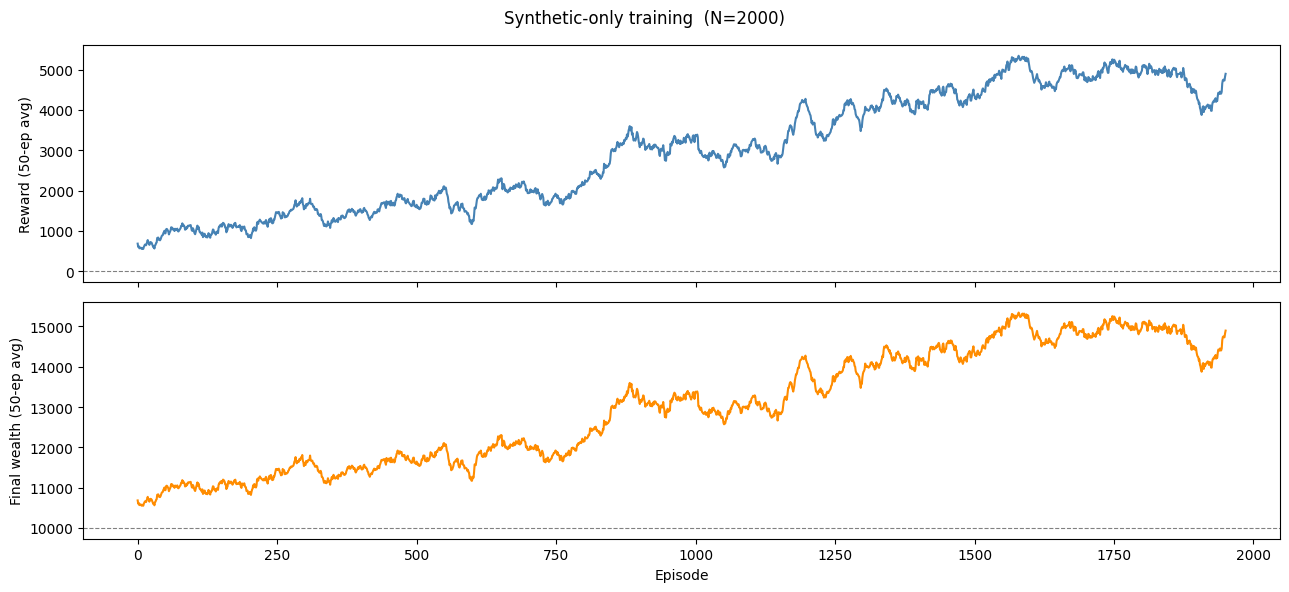

In [11]:
# ── Synthetic-only agent ─────────────────────────────────────────────────
# Re-init a fresh agent and train 100% on synthetic windows.

agent_syn = DoubleDQN(
    state_dim       = STATE_DIM,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = int(N_EPISODES * EPISODE_LEN * 0.8),
    grad_clip       = 1.0,
)

N_SYN       = N_EPISODES
TRAIN_FREQ  = 4
LOG_EVERY   = 100

syn_rewards = []
syn_wealth  = []
syn_losses  = []
total_steps = 0

for ep in range(N_SYN):
    ep_prices, b, icp = make_synthetic_window(rng)
    env = PairTradingEnv(
        ep_prices,
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=EPISODE_LEN, z_windows=Z_WINDOWS, simple_obs=True,
    )

    obs, _ = env.reset()
    done    = False
    ep_r    = 0.0

    while not done:
        action = agent_syn.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent_syn.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1
        if total_steps % TRAIN_FREQ == 0:
            loss = agent_syn.train()
            if loss is not None:
                syn_losses.append(loss)

    syn_rewards.append(ep_r)
    syn_wealth.append(env._wealth())

    if (ep + 1) % LOG_EVERY == 0:
        print(f'ep {ep+1:5d} | avg_reward {np.mean(syn_rewards[-LOG_EVERY:]):+8.2f} '
              f'| avg_wealth {np.mean(syn_wealth[-LOG_EVERY:]):8.2f} '
              f'| eps {agent_syn.epsilon:.3f}')

# Training curves
roll = 50; kern = np.ones(roll) / roll
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(f'Synthetic-only training  (N={N_SYN})', fontsize=12)
axes[0].plot(np.convolve(syn_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel(f'Reward ({roll}-ep avg)')
axes[1].plot(np.convolve(syn_wealth,  kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel(f'Final wealth ({roll}-ep avg)')
axes[1].set_xlabel('Episode')
plt.tight_layout()
plt.show()

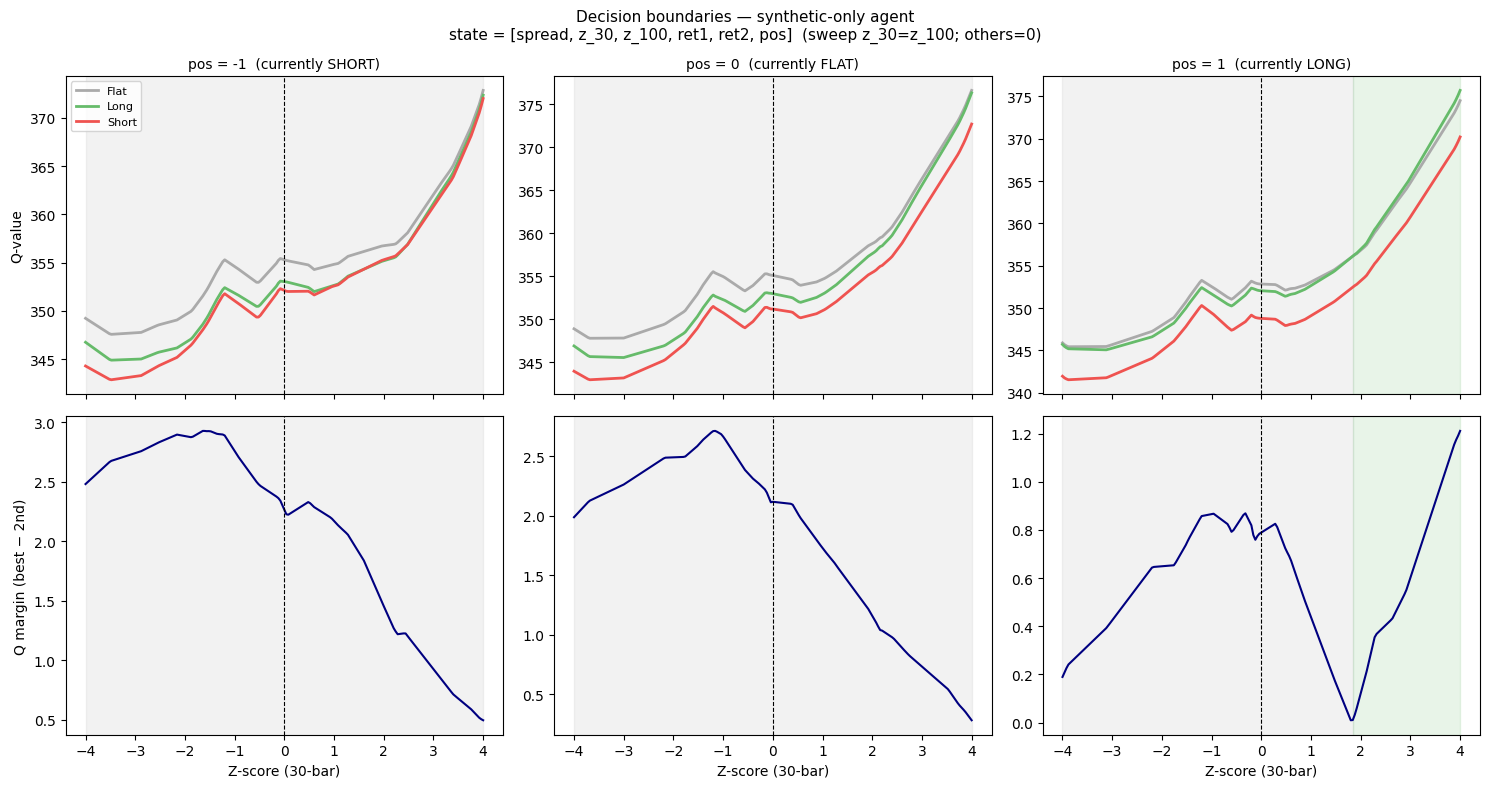


Action thresholds:
  pos=-1:   always Flat
  pos=+0:   always Flat
  pos=+1:   z=+1.84: Flat→Long


In [12]:
# ── Decision boundaries (synthetic-only agent) ───────────────────────────
# State = [spread, z_30, z_100, ret1, ret2, pos]
# To visualise: fix spread=0, z_100=z_30, ret1=ret2=0; sweep z_30 and vary pos.

ACT_NAMES  = {0: 'Flat', 1: 'Long', 2: 'Short'}
ACT_COLORS = {0: '#aaaaaa', 1: '#66bb6a', 2: '#ef5350'}
POS_LABELS = {-1: 'currently SHORT', 0: 'currently FLAT', 1: 'currently LONG'}

z_vals = np.linspace(-4.0, 4.0, 201)
positions = [-1, 0, 1]

agent_syn.q_net.eval()

Q_all = np.zeros((3, len(z_vals), 3))
with torch.no_grad():
    for pi, pos in enumerate(positions):
        for zi, z in enumerate(z_vals):
            # [spread=0, z_30=z, z_100=z, ret1=0, ret2=0, pos]
            obs = torch.tensor([0.0, z, z, 0.0, 0.0, float(pos)], dtype=torch.float32).unsqueeze(0)
            Q_all[pi, zi] = agent_syn.q_net(obs).numpy()[0]

agent_syn.q_net.train()

best_action = Q_all.argmax(axis=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle('Decision boundaries — synthetic-only agent\n'
             'state = [spread, z_30, z_100, ret1, ret2, pos]  '
             '(sweep z_30=z_100; others=0)', fontsize=11)

for pi, pos in enumerate(positions):
    ax_q  = axes[0, pi]
    ax_m  = axes[1, pi]

    prev_a = best_action[pi, 0]
    seg_start = z_vals[0]
    for zi in range(1, len(z_vals)):
        a = best_action[pi, zi]
        if a != prev_a or zi == len(z_vals) - 1:
            ax_q.axvspan(seg_start, z_vals[zi], alpha=0.15, color=ACT_COLORS[prev_a])
            ax_m.axvspan(seg_start, z_vals[zi], alpha=0.15, color=ACT_COLORS[prev_a])
            seg_start = z_vals[zi]
            prev_a = a

    for a in range(3):
        ax_q.plot(z_vals, Q_all[pi, :, a],
                  color=ACT_COLORS[a], lw=2, label=ACT_NAMES[a])
    ax_q.axvline(0, color='black', lw=0.8, ls='--')
    ax_q.set_title(f'pos = {pos}  ({POS_LABELS[pos]})', fontsize=10)
    ax_q.set_ylabel('Q-value' if pi == 0 else '')
    if pi == 0:
        ax_q.legend(fontsize=8)

    sorted_Q = np.sort(Q_all[pi], axis=1)
    margin   = sorted_Q[:, -1] - sorted_Q[:, -2]
    ax_m.plot(z_vals, margin, color='navy', lw=1.5)
    ax_m.axvline(0, color='black', lw=0.8, ls='--')
    ax_m.set_xlabel('Z-score (30-bar)')
    ax_m.set_ylabel('Q margin (best − 2nd)' if pi == 0 else '')

plt.tight_layout()
plt.show()

print('\nAction thresholds:')
for pi, pos in enumerate(positions):
    changes = []
    for zi in range(1, len(z_vals)):
        if best_action[pi, zi] != best_action[pi, zi-1]:
            changes.append((z_vals[zi], ACT_NAMES[best_action[pi, zi-1]],
                            ACT_NAMES[best_action[pi, zi]]))
    print(f'  pos={pos:+d}: ', end='')
    if changes:
        for z, a_from, a_to in changes:
            print(f'  z={z:+.2f}: {a_from}→{a_to}', end='')
    else:
        print(f'  always {ACT_NAMES[best_action[pi, 0]]}', end='')
    print()

=== Full test region — synthetic-only agent ===
yr 1  [3774–4530)  β=0.470                               $   10543  ret   +5.4%  Sharpe -0.28  MDD -12.4%
yr 2  [4530–5031)  β=1.360                               $   13334  ret  +26.5%  Sharpe  0.71  MDD  -7.1%

FULL TEST REGION                                         $   13334  ret  +33.3%  Sharpe  0.14  MDD -12.4%


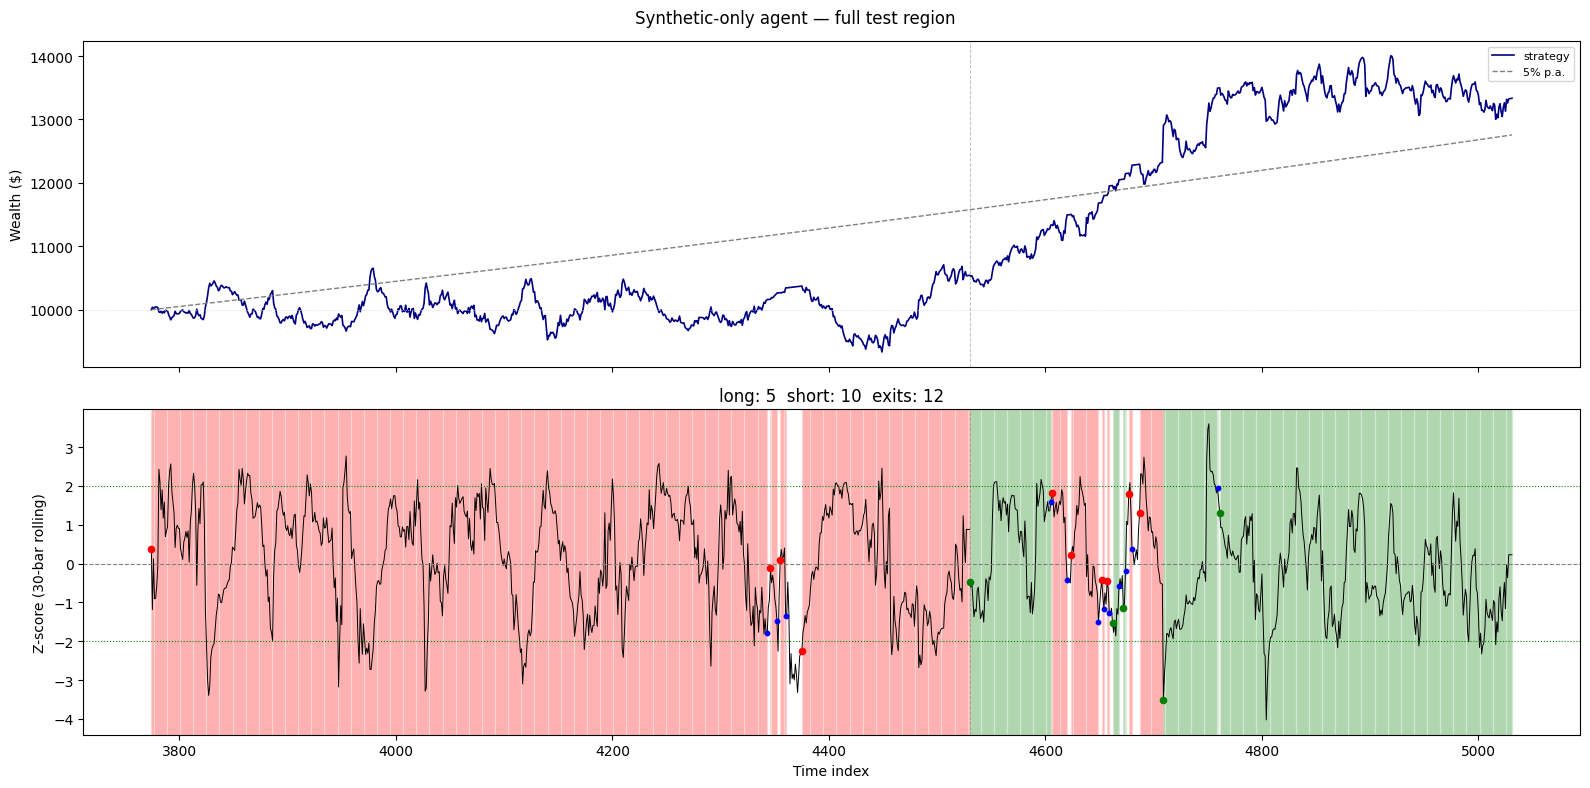

In [13]:
# ── Full test region — synthetic-only agent ───────────────────────────────
# Run consecutive yearly windows; wealth compounds across windows.

print('=== Full test region — synthetic-only agent ===')

all_results  = []
wealth_start = 10_000.0

k = 0
while True:
    t0     = train_end + k * EPISODE_LEN
    ep_len = min(EPISODE_LEN, N - t0 - 1)
    if ep_len <= 0:
        break

    b, icp, _, _ = fit_window_emrt(t0)
    test_env = PairTradingEnv(
        prices[:, t0 : t0 + ep_len + 1],
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=ep_len, z_windows=Z_WINDOWS, simple_obs=True,
        initial_wealth=wealth_start,
    )

    res = evaluate(test_env, agent_syn)
    res['t0']     = t0
    res['ep_len'] = ep_len
    res['beta']   = b
    all_results.append(res)
    wealth_start = float(res['wealth'][-1])

    metrics(res['wealth'], f'yr {k+1}  [{t0}–{t0+ep_len})  β={b:.3f}')
    k += 1

# ── Aggregate metrics ─────────────────────────────────────────────────────
W_full = np.concatenate(
    [all_results[0]['wealth']] +
    [r['wealth'][1:] for r in all_results[1:]]
)
print()
metrics(W_full, 'FULL TEST REGION')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Synthetic-only agent — full test region', fontsize=12)

ax_w = axes[0]
ax_z = axes[1]

t_full = np.concatenate(
    [np.arange(all_results[0]['t0'], all_results[0]['t0'] + all_results[0]['ep_len'] + 1)] +
    [np.arange(r['t0'] + 1, r['t0'] + r['ep_len'] + 1) for r in all_results[1:]]
)
bench = W_full[0] * (1 + _RF_DAILY) ** np.arange(len(W_full))

ax_w.plot(t_full, W_full, color='navy', lw=1.2, label='strategy')
ax_w.plot(t_full, bench,  color='gray', lw=1.0, ls='--', label='5% p.a.')
ax_w.axhline(W_full[0], color='lightgray', lw=0.6, ls=':')
ax_w.set_ylabel('Wealth ($)')
ax_w.legend(fontsize=8)

total_long = total_short = total_exits = 0

for res in all_results:
    t0_r   = res['t0']
    ep_len = res['ep_len']
    t_ep   = np.arange(t0_r, t0_r + ep_len + 1)
    z_ep   = res['z']
    pos_ep = res['pos']

    ax_z.plot(t_ep, z_ep, color='black', lw=0.7)

    for i in range(ep_len):
        if pos_ep[i] == 1:
            ax_z.axvspan(t_ep[i], t_ep[i+1], alpha=0.10, color='green')
        elif pos_ep[i] == -1:
            ax_z.axvspan(t_ep[i], t_ep[i+1], alpha=0.10, color='red')

    for i in res['entries_long']:
        ax_z.scatter(t_ep[i], z_ep[i], color='green', s=20, zorder=5)
    for i in res['entries_short']:
        ax_z.scatter(t_ep[i], z_ep[i], color='red',   s=20, zorder=5)
    for i in res['exits']:
        ax_z.scatter(t_ep[i], z_ep[i], color='blue',  s=10, zorder=5)

    total_long  += len(res['entries_long'])
    total_short += len(res['entries_short'])
    total_exits += len(res['exits'])

    if res is not all_results[-1]:
        ax_w.axvline(t0_r + ep_len, color='gray', lw=0.7, ls='--', alpha=0.5)
        ax_z.axvline(t0_r + ep_len, color='gray', lw=0.7, ls='--', alpha=0.5)

ax_z.axhline( 0,   color='gray',  lw=0.8, ls='--')
ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')
ax_z.set_ylabel(f'Z-score ({Z_WINDOWS[0]}-bar rolling)')
ax_z.set_xlabel('Time index')
ax_z.set_title(f'long: {total_long}  short: {total_short}  exits: {total_exits}')

plt.tight_layout()
plt.show()